딥러닝 파이토치 교과서

12. 강화학습 p.658-673

### 12.4 큐-러닝

12.4.1 큐 러닝 (Q-learning)

- 강화학습 기법 중 하나로 마르코프 결정과정에서 최적의 정책을 찾는데 사용
- 행동의 보상 기댓값을 예측하는 큐함수를 사용해 최적화된 정책을 학습. 여러 episode 반복하며 학습
- 임계치보다 낮으면 랜덤행동(탐험) -> 점점 임계치를 낮게 함 -> 임계치는 0에 수렴하고 경험을 바탕으로 좋은 선택(활용)을 많이 함(상태와 행동에 대한 큐 값 업데이트 반복)
  - 새로운 시도와 경험기반의 선택 사이의 균형이 중요
- 한계:에이전트가 취할 수 있는 상태 개수가 많은 경우 큐 테이블 구축에 한계, 데이터 간 상관관계로 학습이 어려운 경우


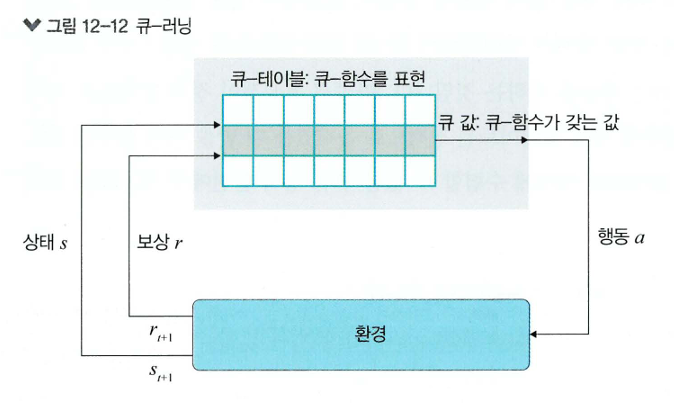

12.4.2 딥 큐 러닝
- 합성곱 신경망을 이용해 큐 함수를 학습하는 강화학습 기법. 합성곱층을 깊게 훈련하면서+큐 값의 정확도 높이는 것이 목표
- 강화학습을 위한 시뮬레이션 환경 구현 함수
  1. reset(): 환경 초기화, 관찰 변수 함께 반환
  2. step(): 에이전트에 명령을 내림. 행동 명력 보내고 환경에서 여러 변수 반환
  3. render(): 화면에 상태 표시

- 타깃 큐 네트워크: 큐 네트워크 외에 별도로 타깃 큐 네트워크를 둬서 주기적으로 한 번씩 업데이트함(수렴에 도움)
  - 손실함수는 MSE 사용. 각 네트워크는 가중치 파라미터만 다름



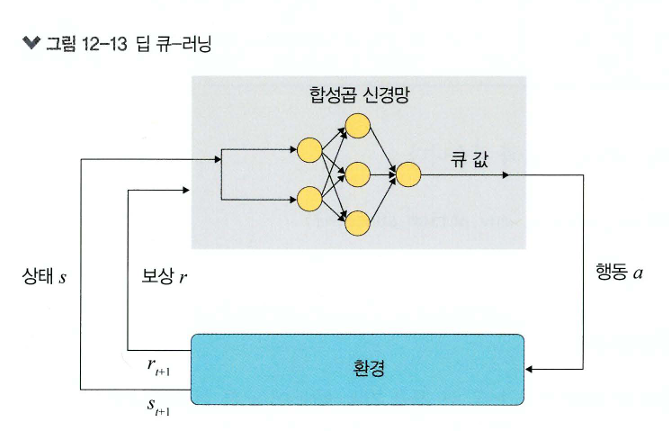

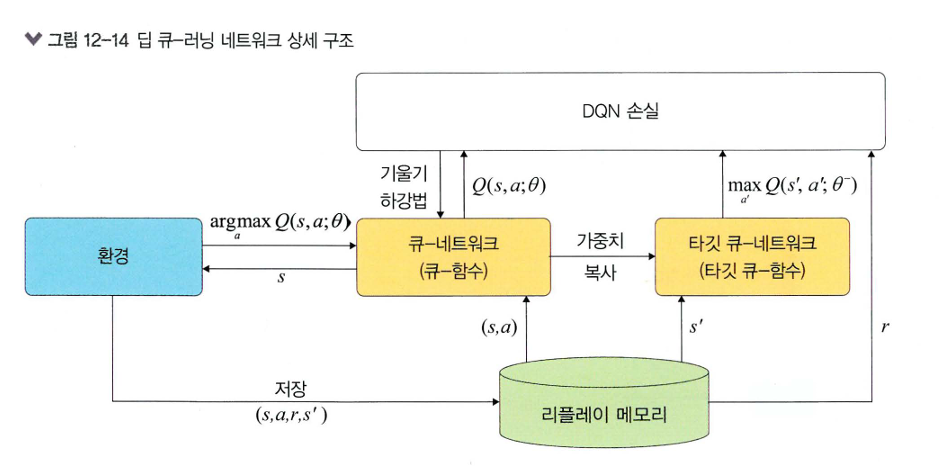

- 리플레이 메모리:
  - 에이전트가 수집한 데이터를 저장하는 저장소. -> 에이전트 상태가 변경되어도 일정 수의 데이터가 수집되도록 기다림 -> 일정 수가 쌓이면 랜덤하게 데이터를 추출해 미니 배치 활용해 학습
  - 데이터 여러개로 훈련한 결과를 모두 수렴해 결과내므로 상관관계 문제 해결!

- 합성곱 신경망을 활용한 큐함수(DQN) - 밑 코드에서는 OpenAI Gym의 CartPole-v1 이용
  - 카트에 부착된 막대기가 수직 상태 유지하도록 중심 찾는 과정을 반복
  - 막대기가 중심에서 너무 멀리 떨어지거나 카트가 중심에서 멀어지면 게임 종료. 오래 지속될수록 많은 보상 얻음
  - 상태: 위치(왼/오), 속도, 가속소
  - 행동: 왼/오

In [1]:
!pip install gym

In [28]:
import gym
import math
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple
from itertools import count
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T

env = gym.make('CartPole-v1').unwrapped
plt.ion()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [29]:
# 리플레이 메모리
Transition = namedtuple('Transition',('state','action','next_state','reward'))

class ReplayMemory(object):
  def __init__(self, capacity):
    self.capacity = capacity
    self.memory = []
    self.position = 0

  def push(self, *args):
    if len(self.memory) < self.capacity:
      self.memory.append(None)
    self.memory[self.position] = Transition(*args)
    self.position = (self.position+1)%self.capacity

  def sample(self, batch_size):
    return random.sample(self.memory, batch_size)

  def __len__(self):
    return len(self.memory)

In [30]:
# DQN 모델 네트워크
class DQN(nn.Module):
  def __init__(self, h, w, outputs):
    super(DQN, self).__init__()
    self.conv1 = nn.Conv2d(3, 16, kernel_size=5, stride=2)
    self.bn1 = nn.BatchNorm2d(16)
    self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=2)
    self.bn2 = nn.BatchNorm2d(32)
    self.conv3 = nn.Conv2d(32, 32, kernel_size=5, stride=2)
    self.bn3 = nn.BatchNorm2d(32)

    def conv2d_size_out(size, kernel_size=5, stride=2):
      return(size - (kernel_size-1)-1) // stride +1

    convw =conv2d_size_out(conv2d_size_out(conv2d_size_out(w)))
    convh =conv2d_size_out(conv2d_size_out(conv2d_size_out(h)))
    linear_input_size = convw * convh * 32
    self.head = nn.Linear(linear_input_size, outputs)

  def forward(self, x):
    x = F.relu(self.bn1(self.conv1(x)))
    x = F.relu(self.bn2(self.conv2(x)))
    x = F.relu(self.bn3(self.conv3(x)))
    return self.head(x.view(x.size(0), -1))

In [31]:
!pip install pyglet

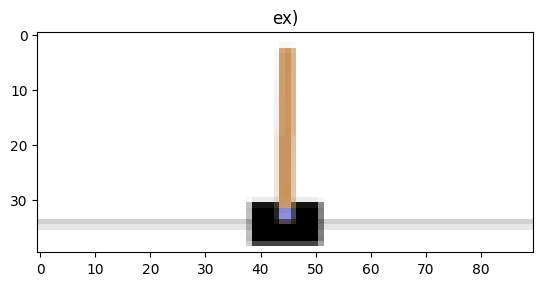

In [32]:
# 이미지 추출 및 처리
import pyglet
import torchvision.transforms as T
from PIL import Image

resize = T.Compose([T.ToPILImage(),
                    T.Resize(40, interpolation = Image.Resampling.BICUBIC),
                    T.ToTensor()])
def get_cart_location(screen_width):
  world_width = env.x_threshold *2
  scale = screen_width / world_width
  return int(env.state[0] * scale +screen_width/2.0)

def get_screen():
  screen = env.render(mode='rgb_array').transpose((2,0,1))
  _, screen_height, screen_width = screen.shape
  screen = screen[:, int(screen_height*0.4):int(screen_height*0.8)]
  view_width = int(screen_width*0.6)
  cart_location = get_cart_location(screen_width)

  if cart_location < view_width // 2:
    slice_range = slice(view_width)
  elif cart_location > (screen_width - view_width //2):
    slice_range = slice(-view_width, None)
  else:
    slice_range = slice(cart_location - view_width //2,
                        cart_location + view_width //2)
  screen = screen[:, :, slice_range]
  screen = np.ascontiguousarray(screen, dtype=np.float32) / 255
  screen = torch.from_numpy(screen)
  return resize(screen).unsqueeze(0).to(device)

env.reset()
plt.figure()
plt.imshow(get_screen().cpu().squeeze(0).permute(1,2,0).numpy(),
           interpolation='none')
plt.title('ex)')
plt.show()

In [33]:
# 모델 객채화 및 손실 함수 정의
BATCH_SIZE = 128
GAMMA = 0.999
EPS_START = 0.9
EPS_END = 0.05
EPS_DECAY = 200
TARGET_UPDATE = 10
init_screen = get_screen()
_, _, screen_height, screen_width = init_screen.shape
n_actions = env.action_space.n

policy_net = DQN(screen_height, screen_width, n_actions).to(device)
target_net = DQN(screen_height, screen_width, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.RMSprop(policy_net.parameters())
memory = ReplayMemory(10000)

steps_done = 0

def select_action(state):
  global steps_done
  sample = random.random()
  eps_threshold = EPS_END + (EPS_START - EPS_END)* math.exp(-1.*steps_done / EPS_DECAY)
  steps_done += 1
  if sample > eps_threshold:
    with torch.no_grad():
      return policy_net(state).max(1)[1].view(1,1)
  else:
      return torch.tensor([[random.randrange(n_actions)]], device=device, dtype=torch.long)

episode_durations = []

In [34]:
# 모델에서 사용할 옵티마이저 정의
def optimize_model():
  if len(memory) < BATCH_SIZE:
    return

  transitions = memory.sample(BATCH_SIZE)
  batch = Transition(*zip(*transitions))
  non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
  non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])

  state_batch = torch.cat(batch.state)
  action_batch = torch.cat(batch.action)
  reward_batch = torch.cat(batch.reward)

  state_action_values = policy_net(state_batch).gather(1, action_batch)
  next_state_values = torch.zeros(BATCH_SIZE, device=device)
  next_state_values[non_final_mask] = target_net(non_final_next_states).max(1)[0].detach()
  expected_state_action_values = (next_state_values*GAMMA)+reward_batch

  loss = F.smooth_l1_loss(state_action_values, expected_state_action_values.unsqueeze(1))
  optimizer.zero_grad()
  loss.backward()

  for param in policy_net.parameters():
    param.grad.data.clamp_(-1,1)
  optimizer.step()

/usr/local/lib/python3.12/dist-packages/gym/core.py:43: DeprecationWarning: WARN: The argument mode in render method is deprecated; use render_mode during environment initialization instead.
See here for more information: https://www.gymlibrary.ml/content/api/
  deprecation(


end


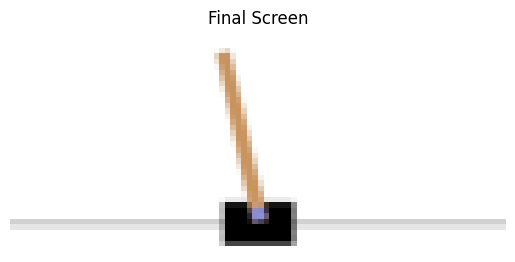

In [37]:
# 모델 학습
num_episode = 50 # 300회 이상이어야 정확한 결과나옴
for i_episode in range(num_episode):
  env.reset()
  last_screen = get_screen()
  current_screen = get_screen()
  state = current_screen - last_screen

  for t in count():
    action = select_action(state)
    _, reward, terminated, truncated, _ = env.step(action.item())
    done = terminated or truncated
    reward = torch.tensor([reward], device=device)

    last_screen = current_screen
    current_screen = get_screen()

    if not done:
      next_state = current_screen - last_screen
    else:
      next_state = None
    memory.push(state, action, next_state, reward)
    state = next_state

    optimize_model()
    if done:
      episode_durations.append(t+1)
      break

  if i_episode % TARGET_UPDATE == 0:
    target_net.load_state_dict(policy_net.state_dict())

print('end')

final_screen = get_screen().cpu().squeeze(0).permute(1, 2, 0).numpy()
plt.figure()
plt.imshow(final_screen, interpolation='none')
plt.title('Final Screen')
plt.axis('off')
plt.show()
env.close()

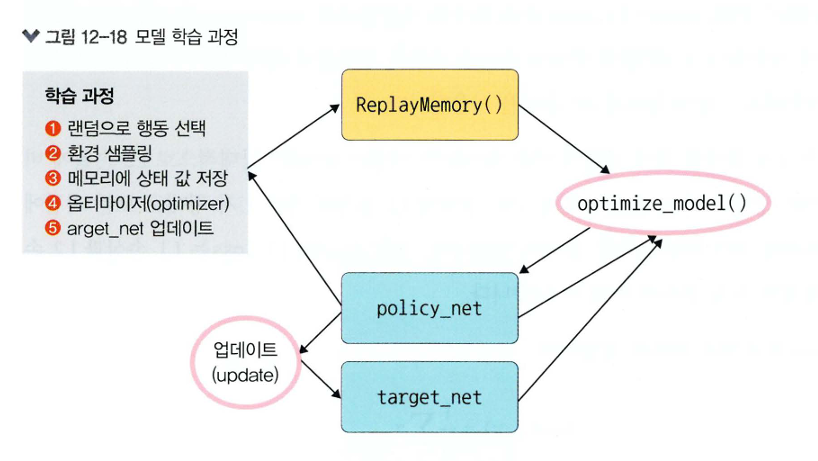